In [159]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [160]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nih-chest-xrays/data",
    "Data_Entry_2017.csv"
)

print(df.shape)
print(df.head())

(112120, 12)
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143 

In [161]:
print ("Dataset Shape:",df.shape)
print(("\nColumns"))
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Value")
print(df.isnull().sum())


Dataset Shape: (112120, 12)

Columns
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

Data Types:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
dtype: object

Missing Value
Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position             

In [162]:
label_counts=df["Finding Labels"].value_counts()
print(label_counts.head(20))


Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64


In [163]:
indivisual_labels=df["Finding Labels"].str.split("|").explode()
label_distribution=indivisual_labels.value_counts()
print(label_distribution)

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64


In [164]:
pneumonia_positive = df["Finding Labels"].str.contains(
    "Pneumonia", 
    case=False, 
    na=False
)

print("Pneumonia-positive images:", pneumonia_positive.sum())
print("Pneumonia-negative images:", (~pneumonia_positive).sum())

Pneumonia-positive images: 1431
Pneumonia-negative images: 110689


In [165]:
total = len(df)

pneumonia_percentage = (pneumonia_positive.sum() / total) * 100
negative_percentage = ((~pneumonia_positive).sum() / total) * 100

print(f"Pneumonia-positive: {pneumonia_percentage:.2f}%")
print(f"Pneumonia-negative: {negative_percentage:.2f}%")

Pneumonia-positive: 1.28%
Pneumonia-negative: 98.72%


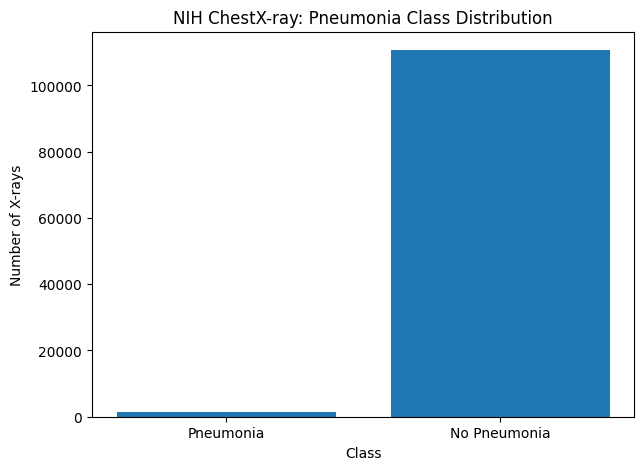

In [166]:
import matplotlib.pyplot as plt

labels = ["Pneumonia", "No Pneumonia"]
counts = [pneumonia_positive.sum(), (~pneumonia_positive).sum()]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)

plt.title("NIH ChestX-ray: Pneumonia Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of X-rays")

plt.show()

In [167]:
unique_patients = df["Patient ID"].nunique()

print("Total X-ray images:", len(df))
print("Unique patients:", unique_patients)

Total X-ray images: 112120
Unique patients: 30805


In [168]:
images_per_patient = df["Patient ID"].value_counts()

print(images_per_patient.describe())


count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000
Name: count, dtype: float64


In [169]:
age_stats = df["Patient Age"].describe()

print(age_stats)

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


In [170]:
invalid_age = df[df["Patient Age"] > 100]

print("Records with age > 100:", len(invalid_age))
print(invalid_age[["Patient ID", "Patient Age"]].head(20))

Records with age > 100: 16
        Patient ID  Patient Age
20852         5567          412
46965        11973          414
48284        12238          148
55742        13950          148
58650        14520          150
62929        15558          149
74884        18366          152
78795        19346          151
84810        20900          411
85404        21047          412
86264        21275          413
91369        22811          412
95794        25206          153
98495        26028          154
101194       26871          155
104590       27989          155


In [171]:
gender_counts = df["Patient Gender"].value_counts()

print(gender_counts)

Patient Gender
M    63340
F    48780
Name: count, dtype: int64


In [172]:
view_counts = df["View Position"].value_counts()

print(view_counts)

View Position
PA    67310
AP    44810
Name: count, dtype: int64


In [173]:
dimension_stats = df[["OriginalImage[Width", "Height]"]].describe()

print(dimension_stats)

       OriginalImage[Width        Height]
count        112120.000000  112120.000000
mean           2646.078844    2486.438842
std             341.246429     401.268227
min            1143.000000     966.000000
25%            2500.000000    2048.000000
50%            2518.000000    2544.000000
75%            2992.000000    2991.000000
max            3827.000000    4715.000000


In [174]:
pixel_spacing_stats = df[[
    "OriginalImagePixelSpacing[x",
    "y]"
]].describe()

print(pixel_spacing_stats)

       OriginalImagePixelSpacing[x             y]
count                112120.000000  112120.000000
mean                      0.155649       0.155649
std                       0.016174       0.016174
min                       0.115000       0.115000
25%                       0.143000       0.143000
50%                       0.143000       0.143000
75%                       0.168000       0.168000
max                       0.198800       0.198800


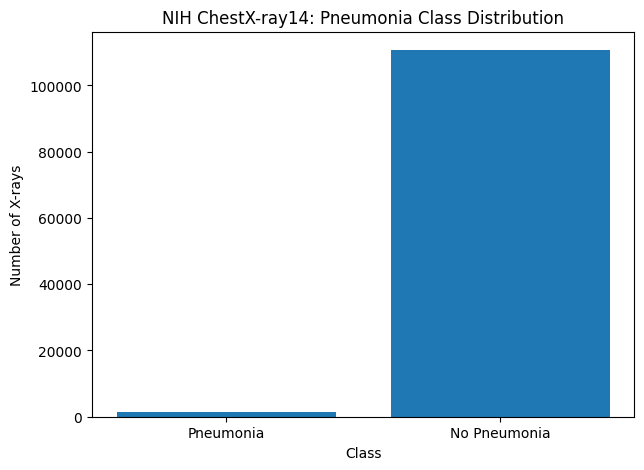

In [175]:
import matplotlib.pyplot as plt

labels = ["Pneumonia", "No Pneumonia"]
counts = [
    pneumonia_positive.sum(),
    (~pneumonia_positive).sum()
]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)

plt.title("NIH ChestX-ray14: Pneumonia Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of X-rays")

plt.show()

In [176]:
import pandas as pd

In [177]:
pneumonia_by_view = pd.crosstab(
    df["View Position"],
    pneumonia_positive
)

print(pneumonia_by_view)

Finding Labels  False  True 
View Position               
AP              44009    801
PA              66680    630


In [178]:
age_data = df[df["Patient Age"] <= 100].copy()

age_data["Age Group"] = pd.cut(
    age_data["Patient Age"],
    bins=[0, 18, 40, 60, 80, 100],
    labels=["0-18", "19-40", "41-60", "61-80", "81-100"]
)

pneumonia_by_age = pd.crosstab(
    age_data["Age Group"],
    age_data["Finding Labels"].str.contains(
        "Pneumonia",
        case=False,
        na=False
    )
)

print(pneumonia_by_age)

Finding Labels  False  True 
Age Group                   
0-18             5825    116
19-40           31547    467
41-60           48953    549
61-80           23478    288
81-100            871     10


In [179]:
pneumonia_by_gender = pd.crosstab(
    df["Patient Gender"],
    pneumonia_positive
)

print(pneumonia_by_gender)

Finding Labels  False  True 
Patient Gender              
F               48187    593
M               62502    838


In [180]:
import os

print("path variable exists:", "path" in globals())

if "path" in globals():
    print("Path:", path)
    print("Exists:", os.path.exists(path))

path variable exists: False


In [181]:
import os

cache_dir = os.path.expanduser("~/.cache/kagglehub")

print("Cache directory:", cache_dir)
print("Exists:", os.path.exists(cache_dir))

if os.path.exists(cache_dir):
    print("\nContents:")
    print(os.listdir(cache_dir))

Cache directory: /Users/sakshammangla/.cache/kagglehub
Exists: True

Contents:
['datasets']


In [182]:
import os

datasets_dir = os.path.expanduser("~/.cache/kagglehub/datasets")

for root, dirs, files in os.walk(datasets_dir):
    level = root.replace(datasets_dir, "").count(os.sep)
    if level > 3:
        dirs[:] = []
        continue

    print("\n" + root)
    for file in files[:10]:
        print("  ", file)


/Users/sakshammangla/.cache/kagglehub/datasets

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays/data
   3.archive

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays/data/versions

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays/data/.complete

/Users/sakshammangla/.cache/kagglehub/datasets/shuofxz

/Users/sakshammangla/.cache/kagglehub/datasets/shuofxz/titanic-machine-learning-from-disaster
   1.complete

/Users/sakshammangla/.cache/kagglehub/datasets/shuofxz/titanic-machine-learning-from-disaster/versions
   .DS_Store


In [183]:
import os

datasets_dir = os.path.expanduser("~/.cache/kagglehub/datasets")

for root, dirs, files in os.walk(datasets_dir):
    level = root.replace(datasets_dir, "").count(os.sep)
    if level > 3:
        dirs[:] = []
        continue

    print("\n" + root)
    for file in files[:10]:
        print("  ", file)


/Users/sakshammangla/.cache/kagglehub/datasets

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays/data
   3.archive

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays/data/versions

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays/data/.complete

/Users/sakshammangla/.cache/kagglehub/datasets/shuofxz

/Users/sakshammangla/.cache/kagglehub/datasets/shuofxz/titanic-machine-learning-from-disaster
   1.complete

/Users/sakshammangla/.cache/kagglehub/datasets/shuofxz/titanic-machine-learning-from-disaster/versions
   .DS_Store


In [184]:
import os

archive_path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/nih-chest-xrays/data/3.archive"
)

print("Archive exists:", os.path.exists(archive_path))
print("Archive size:", round(os.path.getsize(archive_path) / (1024**3), 2), "GB")

Archive exists: True
Archive size: 1.92 GB


In [185]:
import os

archive_path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/nih-chest-xrays/data/3.archive"
)

with open(archive_path, "rb") as f:
    header = f.read(16)

print("First 16 bytes:", header)

First 16 bytes: b'PK\x03\x04-\x00\x00\x00\x08\x00\xc6\x019O\x99\x1a'


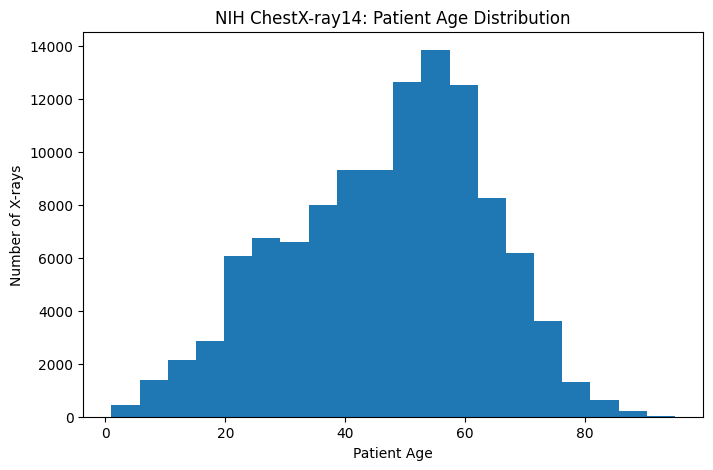

In [186]:
import matplotlib.pyplot as plt

age_data = df[df["Patient Age"] <= 100]

plt.figure(figsize=(8, 5))
plt.hist(age_data["Patient Age"], bins=20)
plt.title("NIH ChestX-ray14: Patient Age Distribution")
plt.xlabel("Patient Age")
plt.ylabel("Number of X-rays")
plt.show()

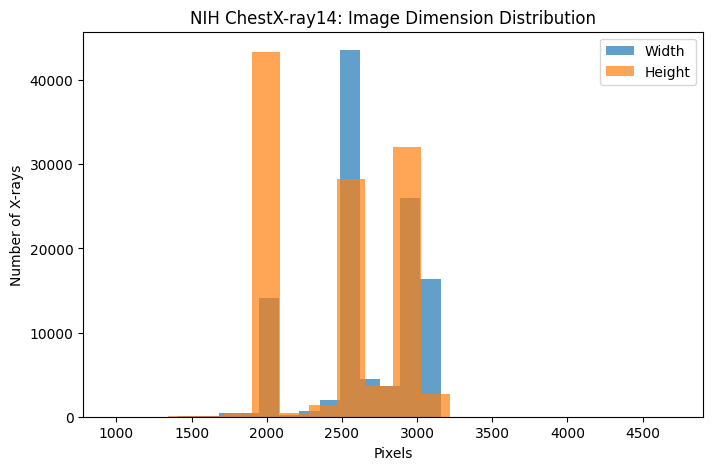

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["OriginalImage[Width"], bins=20, alpha=0.7, label="Width")
plt.hist(df["Height]"], bins=20, alpha=0.7, label="Height")

plt.title("NIH ChestX-ray14: Image Dimension Distribution")
plt.xlabel("Pixels")
plt.ylabel("Number of X-rays")
plt.legend()
plt.show()

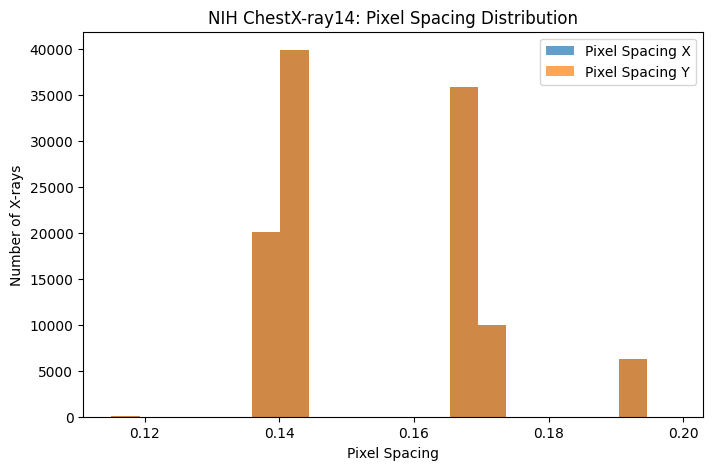

In [188]:
plt.figure(figsize=(8, 5))

plt.hist(df["OriginalImagePixelSpacing[x"], bins=20, alpha=0.7, label="Pixel Spacing X")
plt.hist(df["y]"], bins=20, alpha=0.7, label="Pixel Spacing Y")

plt.title("NIH ChestX-ray14: Pixel Spacing Distribution")
plt.xlabel("Pixel Spacing")
plt.ylabel("Number of X-rays")
plt.legend()
plt.show()

In [189]:
followup_counts = df["Follow-up #"].value_counts().sort_index()

print(followup_counts.head(20))
print("\nMaximum Follow-up #:", df["Follow-up #"].max())

Follow-up #
0     30805
1     13302
2      9189
3      7089
4      5759
5      4821
6      4034
7      3426
8      2932
9      2545
10     2225
11     1944
12     1709
13     1544
14     1363
15     1242
16     1122
17     1031
18      954
19      877
Name: count, dtype: int64

Maximum Follow-up #: 183


In [190]:
import os

base = os.path.expanduser(
    "~/.cache/kagglehub/datasets/nih-chest-xrays"
)

for root, dirs, files in os.walk(base):
    image_files = [
        f for f in files
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if image_files:
        print("Found images in:", root)
        print("Number here:", len(image_files))
        print("Examples:", image_files[:5])
        break

In [191]:
import subprocess

result = subprocess.run(
    ["file", archive_path],
    capture_output=True,
    text=True
)

print(result.stdout)

/Users/sakshammangla/.cache/kagglehub/datasets/nih-chest-xrays/data/3.archive: Zip archive data, at least v4.5 to extract, compression method=deflate



In [192]:
import subprocess

result = subprocess.run(
    ["zipinfo", "-1", archive_path],
    capture_output=True,
    text=True
)

print(result.stdout[:5000])

In [193]:
nih_summary = {
    "Total X-rays": len(df),
    "Unique Patients": df["Patient ID"].nunique(),
    "Pneumonia Positive": pneumonia_positive.sum(),
    "Pneumonia Negative": (~pneumonia_positive).sum(),
    "Male": (df["Patient Gender"] == "M").sum(),
    "Female": (df["Patient Gender"] == "F").sum(),
    "PA Views": (df["View Position"] == "PA").sum(),
    "AP Views": (df["View Position"] == "AP").sum(),
    "Average Age": round(df["Patient Age"].mean(), 2),
    "Average Images per Patient": round(
        len(df) / df["Patient ID"].nunique(), 2
    )
}

for key, value in nih_summary.items():
    print(f"{key}: {value}")

Total X-rays: 112120
Unique Patients: 30805
Pneumonia Positive: 1431
Pneumonia Negative: 110689
Male: 63340
Female: 48780
PA Views: 67310
AP Views: 44810
Average Age: 46.9
Average Images per Patient: 3.64
